In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yaml
from pathlib import Path

# Leggi la config
config_path = Path('../configs/config.yaml')
with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

train_csv_path = Path('../') / config['data']['train_csv']

# Carica i dati
df = pd.read_csv(train_csv_path)
df = df.sort_values(by=['ESN', 'Cycles', 'Snapshot']).reset_index(drop=True)


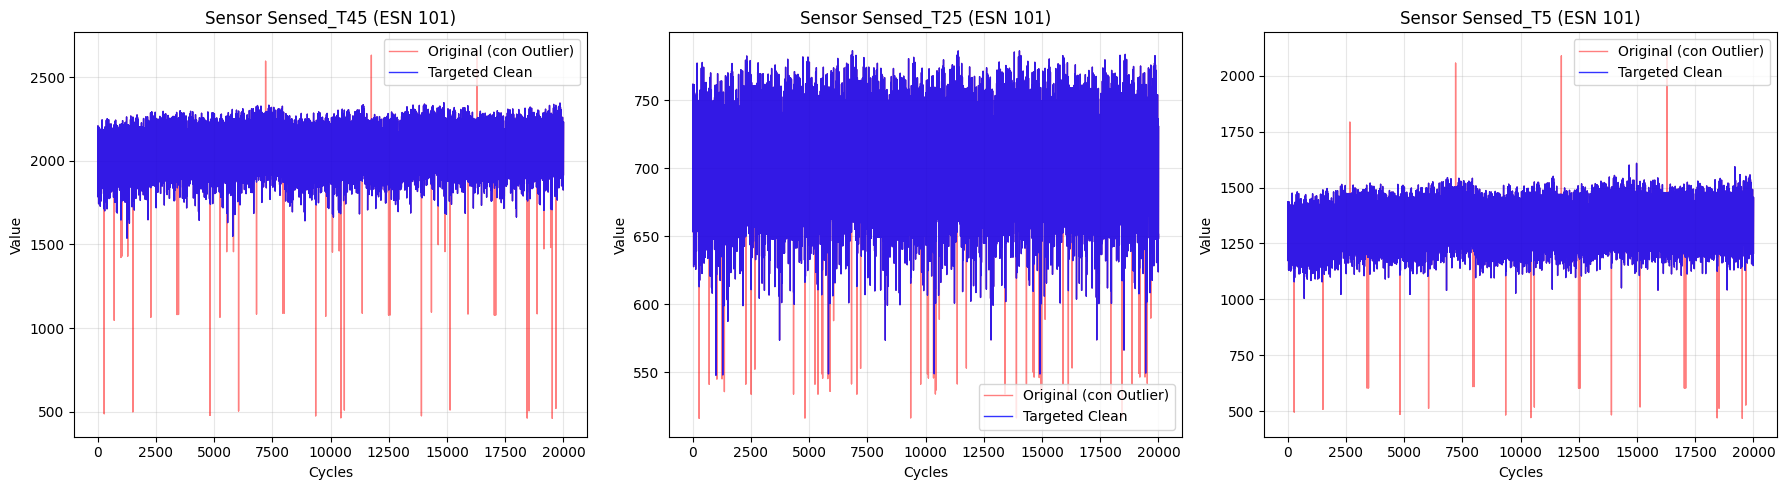

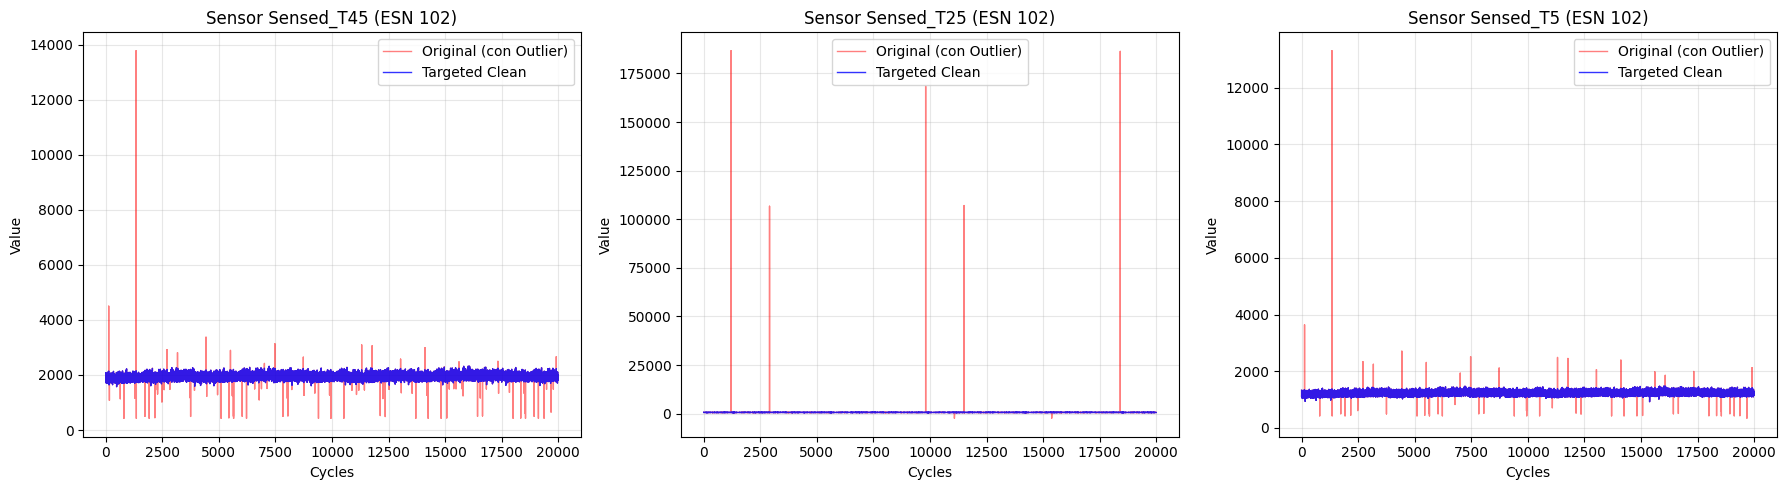

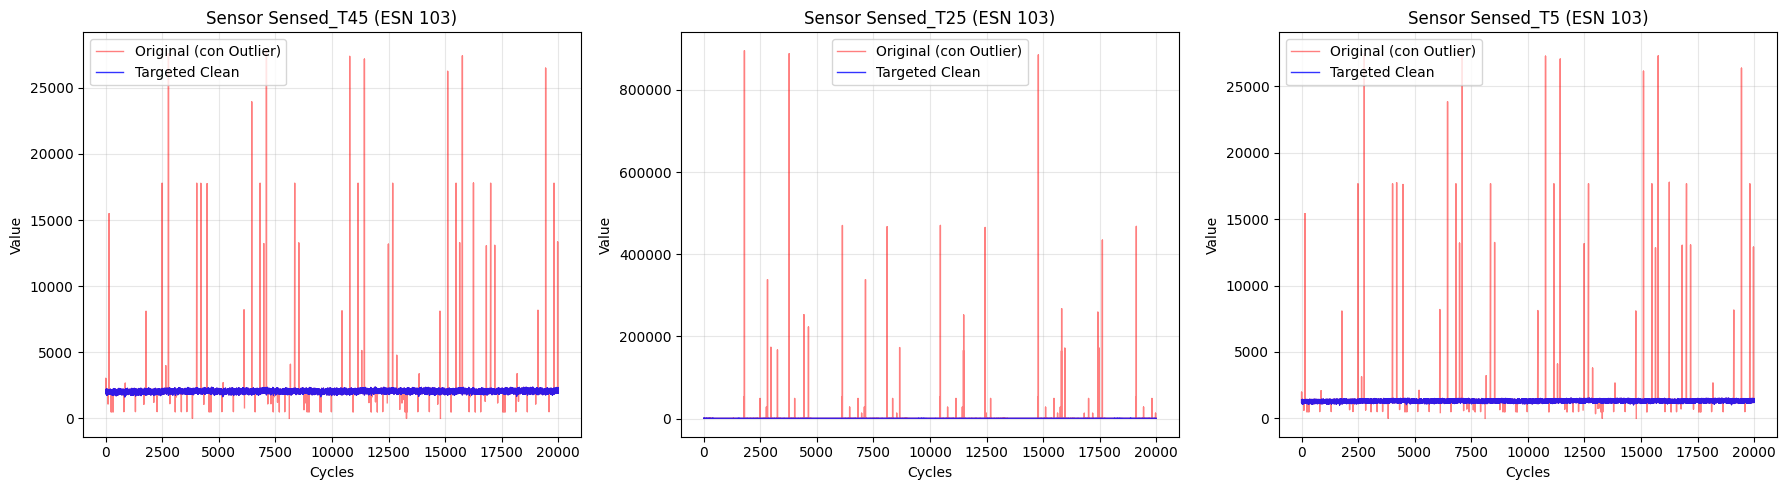

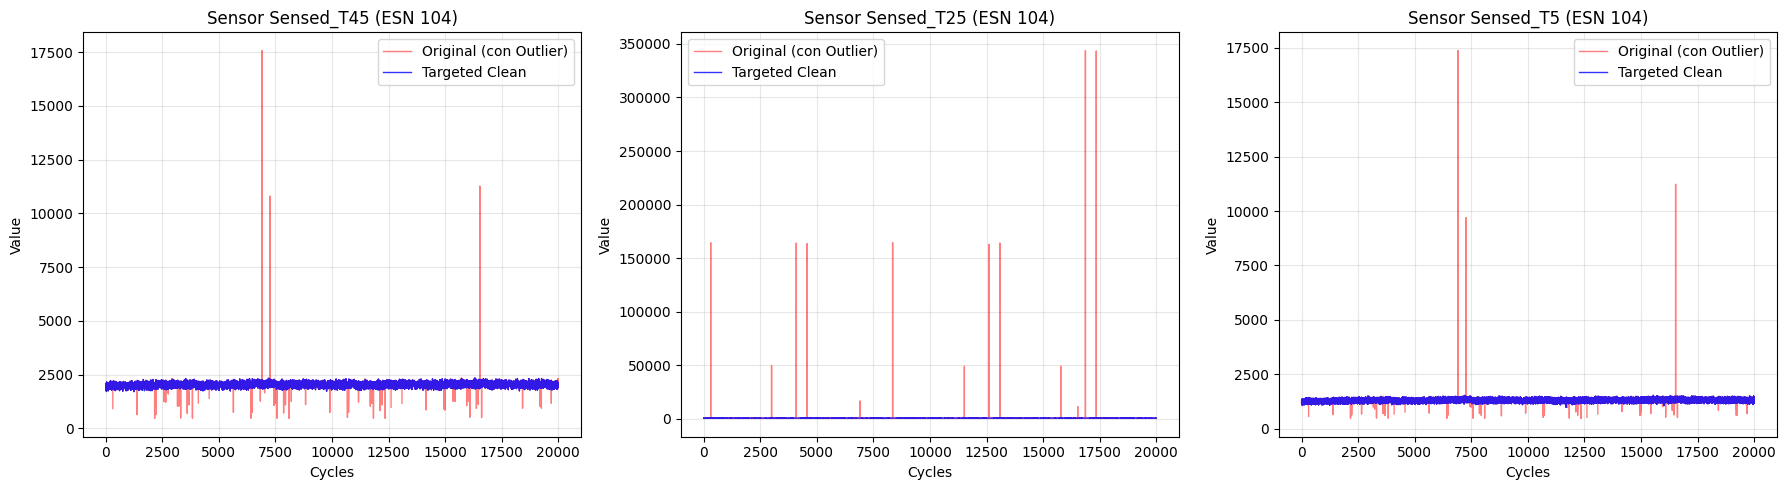

In [7]:

sensor_cols = [col for col in df.columns if col.startswith('Sensed_')]

df_targeted = df.copy()

def hampel_filter(series, window=101, k=3):

    temp = series.interpolate().bfill().ffill()

    rolling_median = temp.rolling(
        window=window,
        center=True,
        min_periods=window//2
    ).median()

    diff = np.abs(temp - rolling_median)

    mad = diff.rolling(
        window=window,
        center=True,
        min_periods=window//2
    ).median()

    threshold = k * 1.4826 * mad  # 1.4826 = scaling for Gaussian

    is_outlier = diff > threshold

    clean = series.copy()
    clean[is_outlier] = rolling_median[is_outlier]

    return clean


for col in sensor_cols:
    df_targeted[col] = df_targeted.groupby('ESN')[col].transform(lambda x: hampel_filter(x))

# Save the targeted cleaned dataset
#result_csv_path = Path('../data/outlier_cleaned_data.csv')
#df_targeted.to_csv(result_csv_path, index=False)

engine_ids = [101, 102, 103, 104]
sensor_to_plot = ['Sensed_T45', 'Sensed_T25','Sensed_T5']


for eid in engine_ids:
    orig = df[df['ESN'] == eid]
    clean = df_targeted[df_targeted['ESN'] == eid]
    cycles = orig['Cycles']

    fig, axes = plt.subplots(1, len(sensor_to_plot), figsize=(18, 5), sharex=True)
    
    for i, col in enumerate(sensor_to_plot):
        axes[i].plot(cycles, orig[col], label='Original (con Outlier)', alpha=0.5, color='red', linewidth=1)
        axes[i].plot(cycles, clean[col], label='Targeted Clean', alpha=0.8, color='blue', linewidth=1)
        axes[i].set_title(f'Sensor {col} (ESN {eid})')
        axes[i].set_xlabel('Cycles')
        axes[i].set_ylabel('Value')
        axes[i].grid(True, alpha=0.3)
        axes[i].legend()
    
    plt.tight_layout()
    plt.show()

c:\Users\tiasb\AppData\Local\Programs\Python\Python310\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\tiasb\AppData\Local\Programs\Python\Python310\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


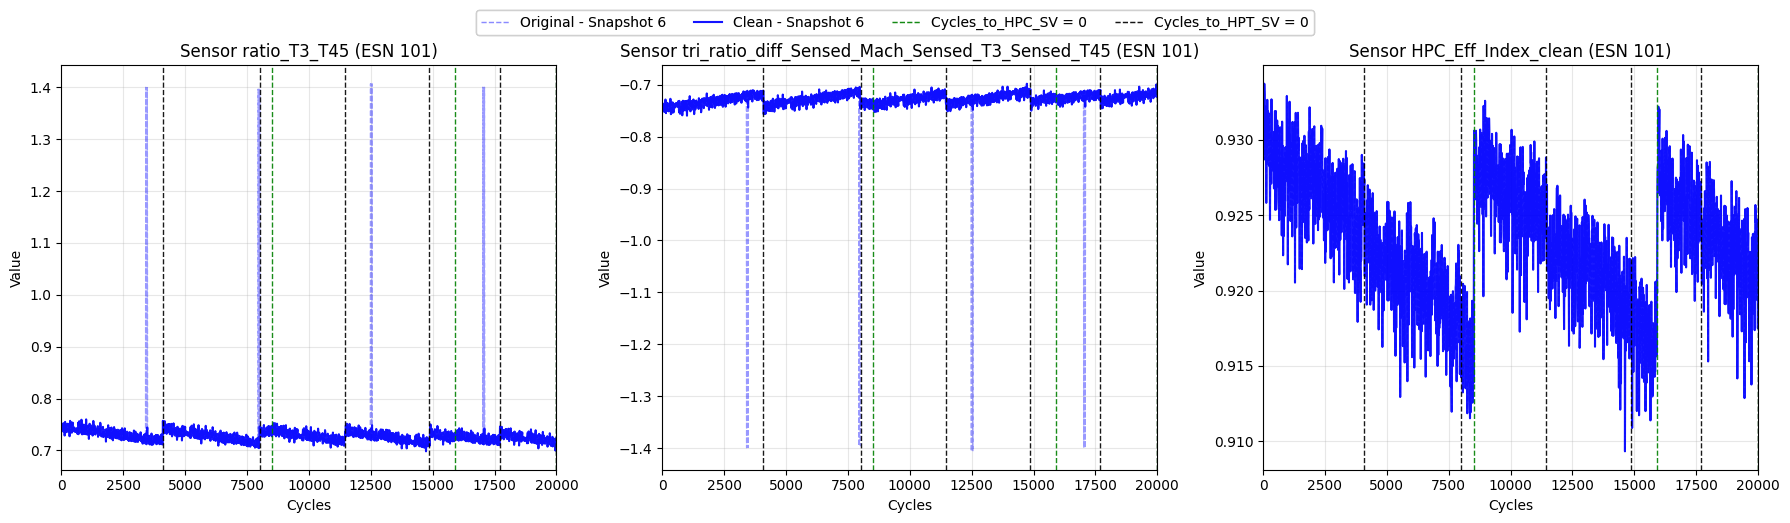

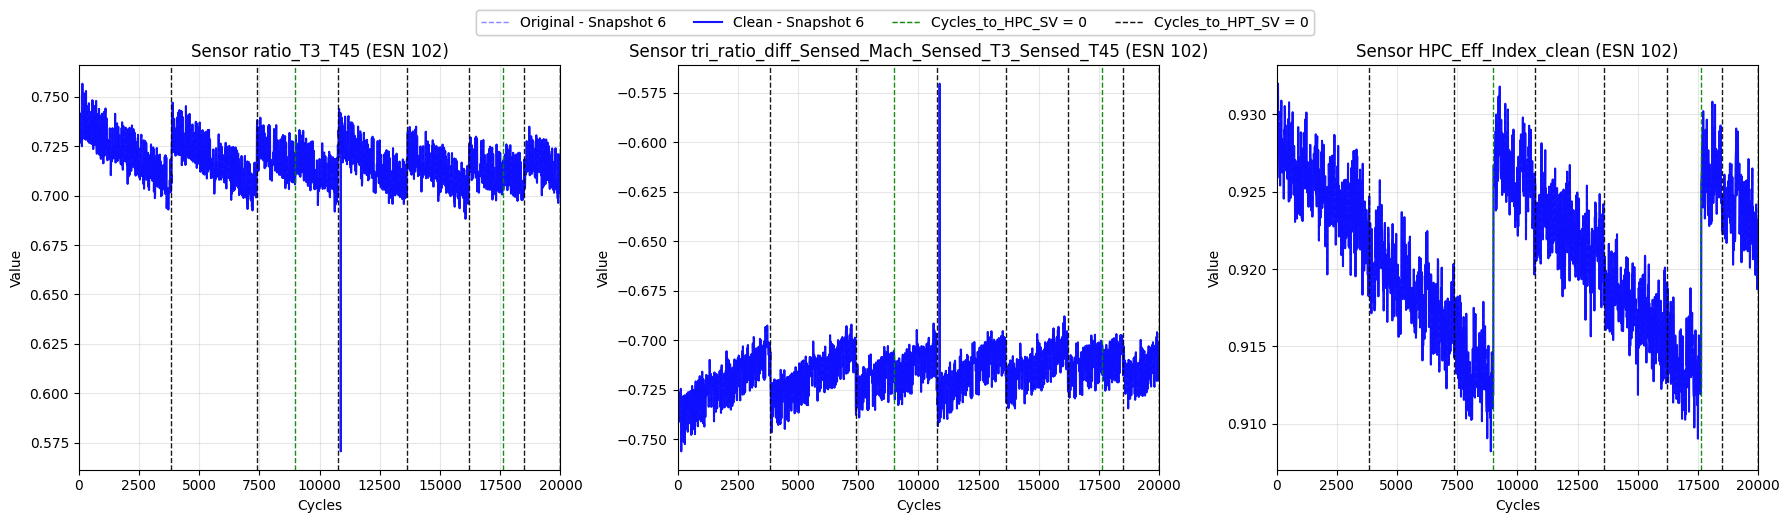

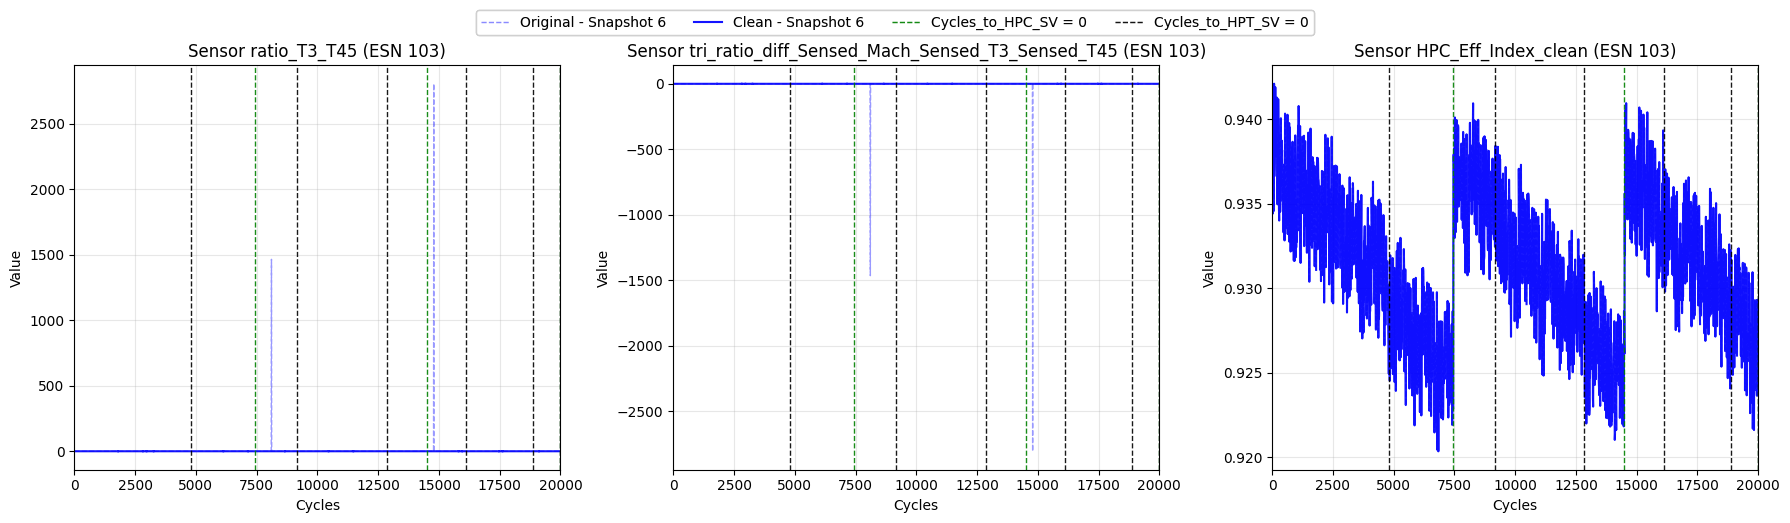

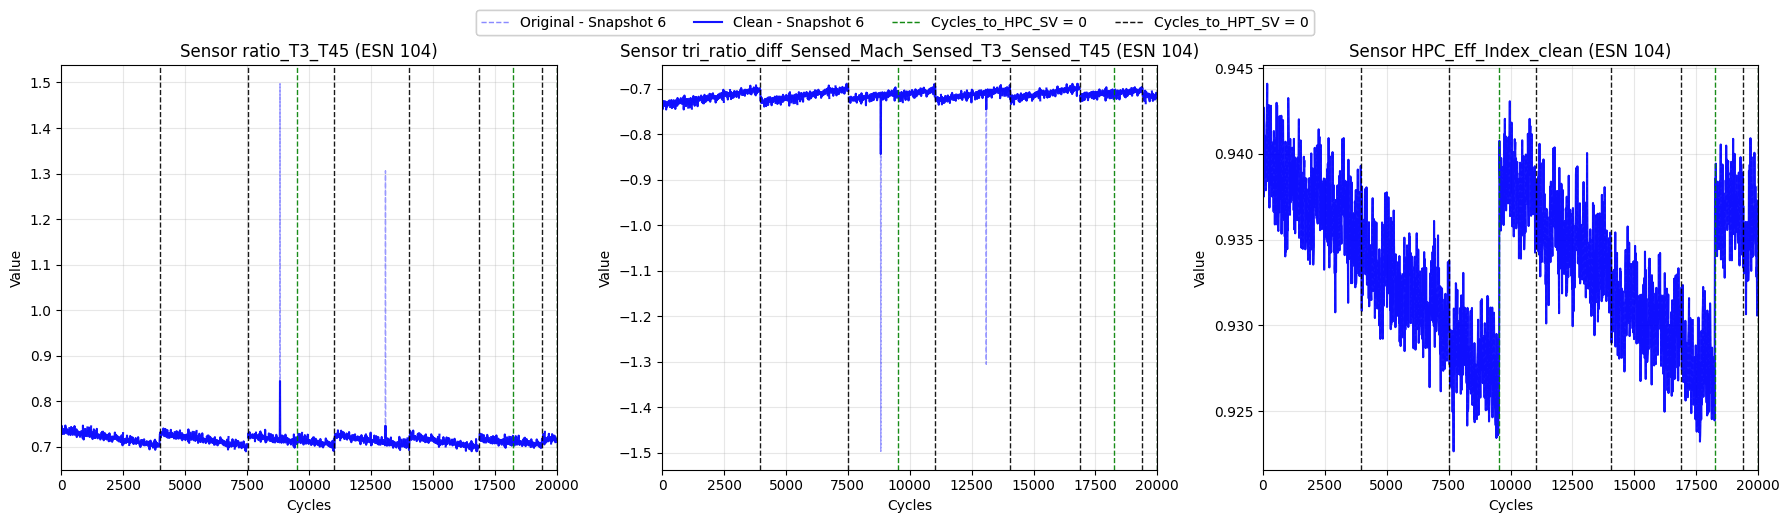

342933.41704206204


In [13]:
engine_ids = [101, 102, 103, 104]
df['ratio_T3_T45'] = df['Sensed_T3'] / (df['Sensed_T45'] + 1e-6)
df['diff_T3_T5'] = df['Sensed_T3'] - df['Sensed_T5']
df['ratio_Core_Speed_T5'] = df['Sensed_Core_Speed'] / (df['Sensed_T5'] + 1e-6)
df['ratio_Ps3_P25'] = df['Sensed_Ps3'] / (df['Sensed_P25'] + 1e-6)
df['ratio_T3_T5'] = df['Sensed_T3'] / (df['Sensed_T5'] + 1e-6)
df['ratio_Pt2_Ps3'] = df['Sensed_Pt2'] / (df['Sensed_Ps3'] + 1e-6)
df['tri_ratio_diff_Sensed_Mach_Sensed_T3_Sensed_T45'] = (df['Sensed_Mach'] - df['Sensed_T3']) / (df['Sensed_T45'] + 1e-6)
# --- 2. Thermodynamic Efficiency Indicators (HPC specific) ---
# HPC Pressure Ratio (PR)
df['HPC_PR'] = df['Sensed_Ps3'] / df['Sensed_P25']
# HPC Temperature Ratio (TR)
df['HPC_TR'] = df['Sensed_T3'] / df['Sensed_T25']
# Efficiency Proxy (Isentropic Efficiency approximation)
gamma = 1.4
df['HPC_Eff_Index'] = (df['HPC_PR']**((gamma-1)/gamma)) / df['HPC_TR']


df['HPC_Eff_Index_clean'] = (
    df.groupby('ESN')['HPC_Eff_Index']
      .transform(lambda x: hampel_filter(x))
)
df_targeted['HPC_Eff_Index_clean'] = df['HPC_Eff_Index_clean']



df['Ratio_N1_T45'] = df['Sensed_Fan_Speed'] / (df['Sensed_T45'])
df['Ratio_N2_WF'] = df['Sensed_Core_Speed'] / (df['Sensed_WFuel'])
df['HPC_Work_Ratio'] = (df['Sensed_Ps3'] - df['Sensed_P25']) / (df['Sensed_T3'] - df['Sensed_T25'])
df['N1_N2_Matching'] = df['Sensed_Fan_Speed'] / df['Sensed_Core_Speed']
df['temp_increment_squared_Sensed_T25_Sensed_T45'] = (df['Sensed_T25'] - df['Sensed_T45'])**2
# Formula: (Ps3 / P25) / (N_core / sqrt(T25))
df['HCLI'] = (df['Sensed_Ps3'] / df['Sensed_P25']) / (df['Sensed_Core_Speed'] / np.sqrt(df['Sensed_T25']))



df_targeted['ratio_T3_T45'] = df_targeted['Sensed_T3'] / (df_targeted['Sensed_T45'] + 1e-6)
df_targeted['diff_T3_T45'] = df_targeted['Sensed_T3'] - df_targeted['Sensed_T45']
df_targeted['ratio_Core_Speed_T45'] = df_targeted['Sensed_Core_Speed'] / (df_targeted['Sensed_T45'] + 1e-6)
df_targeted['ratio_Ps3_P25'] = df_targeted['Sensed_Ps3'] / (df_targeted['Sensed_P25'] + 1e-6)
df_targeted['ratio_T3_T45'] = df_targeted['Sensed_T3'] / (df_targeted['Sensed_T45'] + 1e-6)
df_targeted['ratio_Pt2_Ps3'] = df_targeted['Sensed_Pt2'] / (df_targeted['Sensed_Ps3'] + 1e-6)
df_targeted['tri_ratio_diff_Sensed_Mach_Sensed_T3_Sensed_T45'] = (df_targeted['Sensed_Mach'] - df_targeted['Sensed_T3']) / (df_targeted['Sensed_T45'] + 1e-6)
#df_targeted['HPC_PR'] = df_targeted['Sensed_Ps3'] / df_targeted['Sensed_P25']
#df_targeted['HPC_TR'] = df_targeted['Sensed_T3'] / df_targeted['Sensed_T25']
#df_targeted['HPC_Eff_Index'] = (df_targeted['HPC_PR']**((gamma-1)/gamma)) / df_targeted['HPC_TR']
df_targeted['Ratio_N1_T45'] = df_targeted['Sensed_Fan_Speed'] / (df_targeted['Sensed_T45'])
df_targeted['Ratio_N2_WF'] = df_targeted['Sensed_Core_Speed'] / (df_targeted['Sensed_WFuel'])
df_targeted['HPC_Work_Ratio'] = (df_targeted['Sensed_Ps3'] - df_targeted['Sensed_P25']) / (df_targeted['Sensed_T3'] - df_targeted['Sensed_T25'])
df_targeted['N1_N2_Matching'] = df_targeted['Sensed_Fan_Speed'] / df_targeted['Sensed_Core_Speed']
df_targeted['temp_increment_squared_Sensed_T25_Sensed_T45'] = np.log(df_targeted['Sensed_T25'] - df_targeted['Sensed_T45'])**2
df_targeted['HCLI'] = (df_targeted['Sensed_Ps3'] / df_targeted['Sensed_P25']) / (df_targeted['Sensed_Core_Speed'] / np.sqrt(df_targeted['Sensed_T25']))

sensor_to_plot = ['ratio_T3_T45', 'tri_ratio_diff_Sensed_Mach_Sensed_T3_Sensed_T45','HPC_Eff_Index_clean']

snapshots_to_plot = [6]
colors = {6: 'blue'}


for eid in engine_ids:
    
    fig, axes = plt.subplots(1, len(sensor_to_plot), figsize=(18, 5), sharex=True)


    # ---- Trova eventi target ----
    target_events = df[(df['ESN'] == eid) & (df['Snapshot'] == 4)]
    event_cycles = {}


    for target in ['Cycles_to_HPC_SV', 'Cycles_to_HPT_SV']:
        zero_rows = target_events[target_events[target] == 0]
        if not zero_rows.empty:
            event_cycles[target] = zero_rows['Cycles'].values

    event_colors = {
    'Cycles_to_WW': 'red',
    'Cycles_to_HPC_SV': 'green',
    'Cycles_to_HPT_SV': 'black'
    }

    for i, col in enumerate(sensor_to_plot):
        
        for snap in snapshots_to_plot:
            
            orig = df[(df['ESN'] == eid) & (df['Snapshot'] == snap)]
            clean = df_targeted[(df_targeted['ESN'] == eid) & (df_targeted['Snapshot'] == snap)]
            
            cycles = orig['Cycles']

            axes[i].plot(cycles, orig[col],
                         alpha=0.4,
                         color=colors[snap],
                         linestyle='--',
                         linewidth=1,
                         label=f'Original - Snapshot {snap}')

            axes[i].plot(cycles, clean[col],
                         alpha=0.9,
                         color=colors[snap],
                         linewidth=1.5,
                         label=f'Clean - Snapshot {snap}')

        # ---- Linee verticali eventi ----
        for target, cycle_values in event_cycles.items():
            for cycle_value in cycle_values:
                axes[i].axvline(
                    x=cycle_value,
                    linestyle='--',
                    linewidth=1,
                    color=event_colors[target],
                    alpha=0.9,
                    label=f'{target} = 0'
                )


        axes[i].set_xlim(0, 20000)
        axes[i].set_title(f'Sensor {col} (ESN {eid})')
        axes[i].set_xlabel('Cycles')
        axes[i].set_ylabel('Value')
        axes[i].grid(True, alpha=0.3)
        # ---- Legenda unica per tutta la figura ----
        handles, labels = axes[0].get_legend_handles_labels()

        # Rimuove duplicati mantenendo l’ordine
        unique = dict(zip(labels, handles))

        fig.legend(
            unique.values(),
            unique.keys(),
            loc='upper center',
            ncol=4,
            bbox_to_anchor=(0.5, 1.05)
        )

    #plt.xlim(6000,7000)
    plt.tight_layout()
    plt.show()
    
diff = df_targeted['Sensed_T25'] - df['Sensed_T25']
print(diff[df['ESN']==104].abs().max())
    


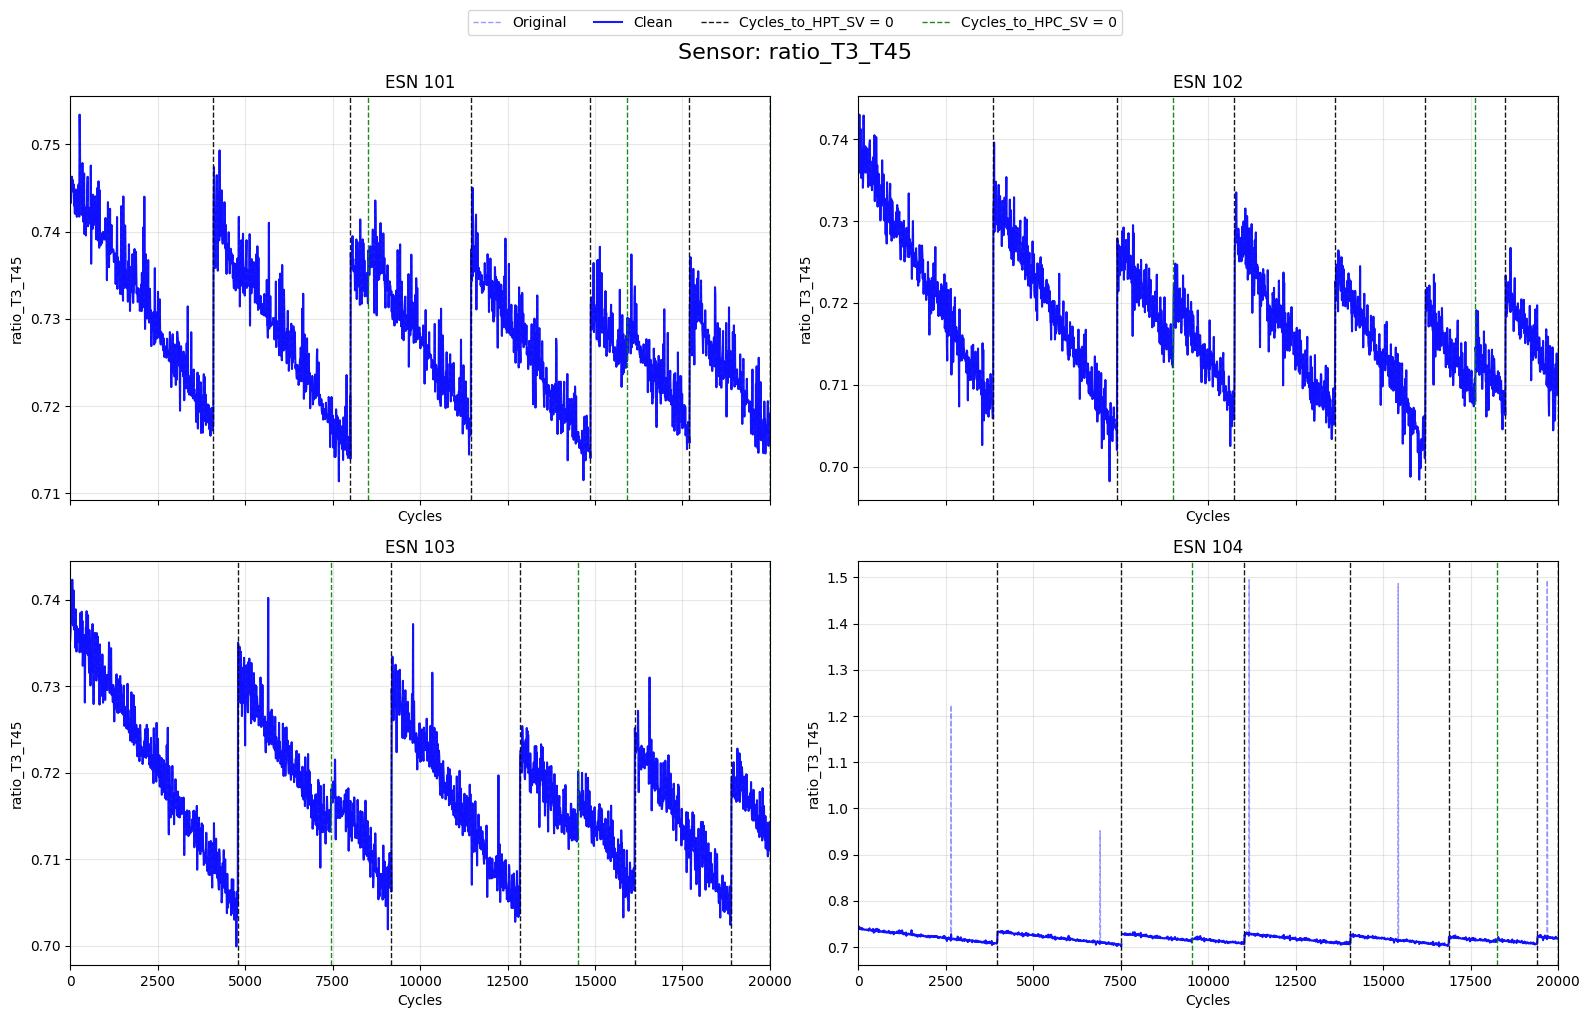

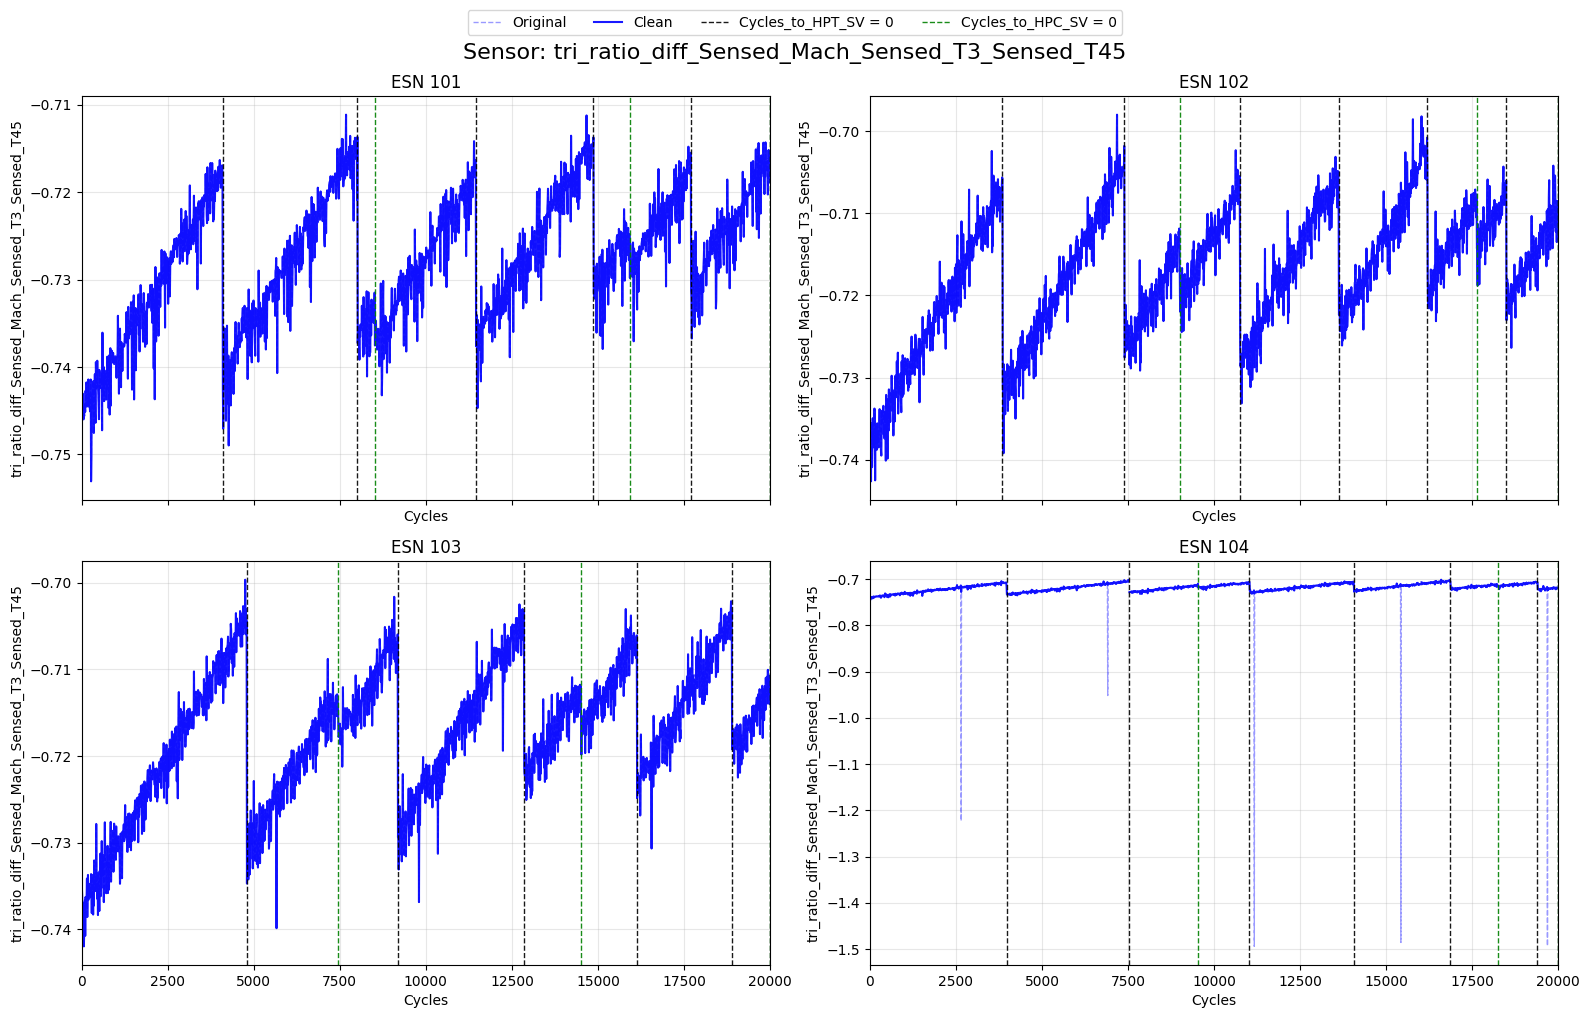

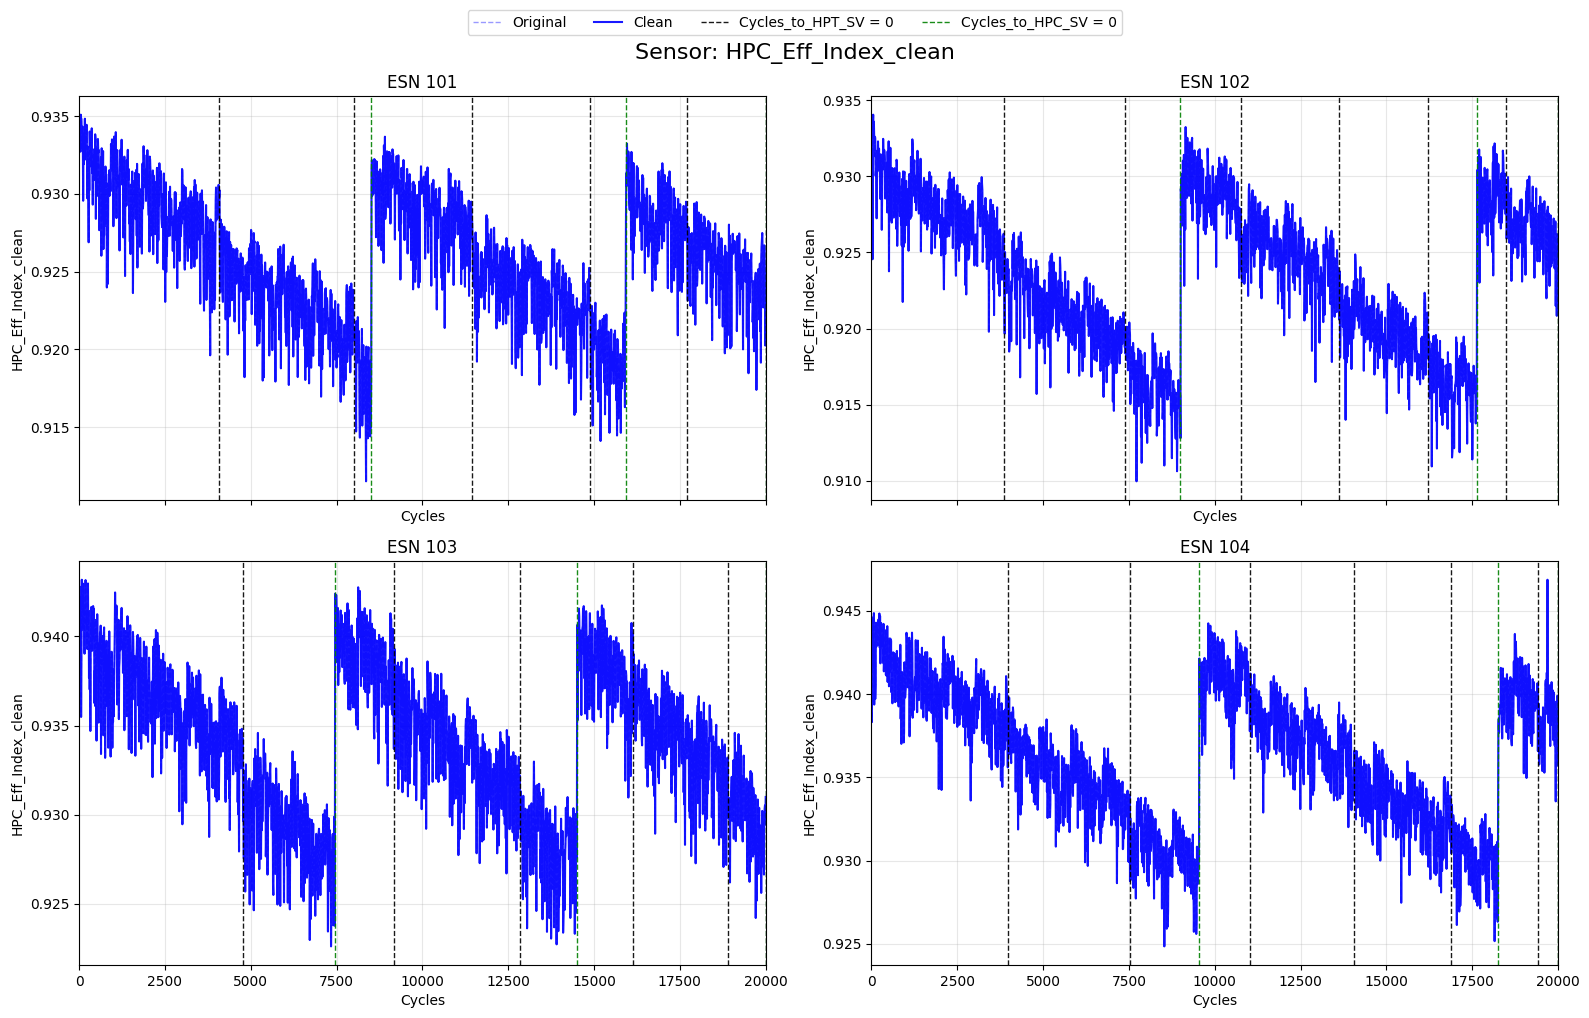

In [9]:
sensor_to_plot = [
    'ratio_T3_T45',
    'tri_ratio_diff_Sensed_Mach_Sensed_T3_Sensed_T45',
    'HPC_Eff_Index_clean'
]

snapshots_to_plot = [4]
colors = {4: 'blue'}

event_colors = {
    'Cycles_to_WW': 'red',
    'Cycles_to_HPC_SV': 'green',
    'Cycles_to_HPT_SV': 'black'
}

for col in sensor_to_plot:

    fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True)
    axes = axes.flatten()

    for idx, eid in enumerate(engine_ids):

        ax = axes[idx]

        # ---- Eventi ----
        target_events = df[(df['ESN'] == eid) & (df['Snapshot'] == 4)]
        event_cycles = {}

        for target in ['Cycles_to_HPT_SV','Cycles_to_HPC_SV']:
            zero_rows = target_events[target_events[target] == 0]
            if not zero_rows.empty:
                event_cycles[target] = zero_rows['Cycles'].values

        # ---- Plot dati ----
        for snap in snapshots_to_plot:

            orig = df[(df['ESN'] == eid) & (df['Snapshot'] == snap)]
            clean = df_targeted[(df_targeted['ESN'] == eid) & (df_targeted['Snapshot'] == snap)]

            ax.plot(orig['Cycles'], orig[col],
                    alpha=0.4,
                    color=colors[snap],
                    linestyle='--',
                    linewidth=1,
                    label='Original')

            ax.plot(orig['Cycles'], clean[col],
                    alpha=0.9,
                    color=colors[snap],
                    linewidth=1.5,
                    label='Clean')

        # ---- Linee eventi ----
        for target, cycle_values in event_cycles.items():
            for cycle_value in cycle_values:
                ax.axvline(
                    x=cycle_value,
                    linestyle='--',
                    linewidth=1,
                    color=event_colors[target],
                    alpha=0.9,
                    label=f'{target} = 0'
                )

        ax.set_xlim(0, 20000)
        ax.set_title(f'ESN {eid}')
        ax.set_xlabel('Cycles')
        ax.set_ylabel(col)
        ax.grid(True, alpha=0.3)

    # ---- Legenda unica per figura ----
    handles, labels = axes[0].get_legend_handles_labels()
    unique = dict(zip(labels, handles))

    fig.legend(unique.values(),
               unique.keys(),
               loc='upper center',
               ncol=4,
               bbox_to_anchor=(0.5, 1.02))

    fig.suptitle(f'Sensor: {col}', fontsize=16)
    plt.tight_layout()
    plt.show()
